In [2]:
import argparse
import os
from pathlib import Path

from autoslo.filesystem.logging import query_latencies_from_log
from autoslo.workload_definition.query import QueryTextId


In [13]:
log_path = Path('/home/markakis/chunkbench/data/runs/1778469201294/structured_log.parquet')

df = query_latencies_from_log(log_path)
df["template_id"] = df["query_text_id"].map(
        lambda qid: int(QueryTextId(qid).template_id)
    )
# Count repetitions of each template_id.
df['repetition_idx'] = df.groupby('template_id').cumcount()

In [14]:
df

,query_id,query_text_id,arrival_s,completion_s,latency_s,template_id,repetition_idx
0,query_0,ext_tpcds1000#035#001,-29.980258,-11.059028,18.921230,35,0
1,query_1,ext_tpcds1000#017#001,-11.057997,1.182472,12.240469,17,0
2,query_10,ext_tpcds1000#044#001,208.211590,239.774232,31.562642,44,0
3,query_100,ext_tpcds1000#019#001,1132.596151,1133.115687,0.519536,19,0
4,query_101,ext_tpcds1000#060#001,1133.116416,1133.836058,0.719642,60,0
...,...,...,...,...,...,...,...
292,query_95,ext_tpcds1000#083#001,1013.219746,1013.743489,0.523743,83,2
293,query_96,ext_tpcds1000#077#001,1013.743949,1014.900224,1.156275,77,2
294,query_97,ext_tpcds1000#023#001,1014.901186,1119.864691,104.963505,23,2
295,query_98,ext_tpcds1000#066#001,1119.865164,1122.435768,2.570604,66,2


In [18]:
pivoted = df.pivot_table(index="template_id", columns="repetition_idx", values="latency_s")
pivoted['median'] = pivoted.median(axis=1)
pivoted

repetition_idx,0,1,2,median
template_id,,,,
1,1.566582,3.203552,1.518630,1.566582
2,11.196698,5.862806,5.920271,5.920271
3,5.734073,7.525994,9.292585,7.525994
4,47.751093,37.610916,38.692487,38.692487
5,4.137072,2.945935,2.303963,2.945935
...,...,...,...,...
95,2.199937,6.080788,2.216708,2.216708
96,3.725135,4.789782,12.438624,4.789782
97,12.489379,12.392328,12.649132,12.489379


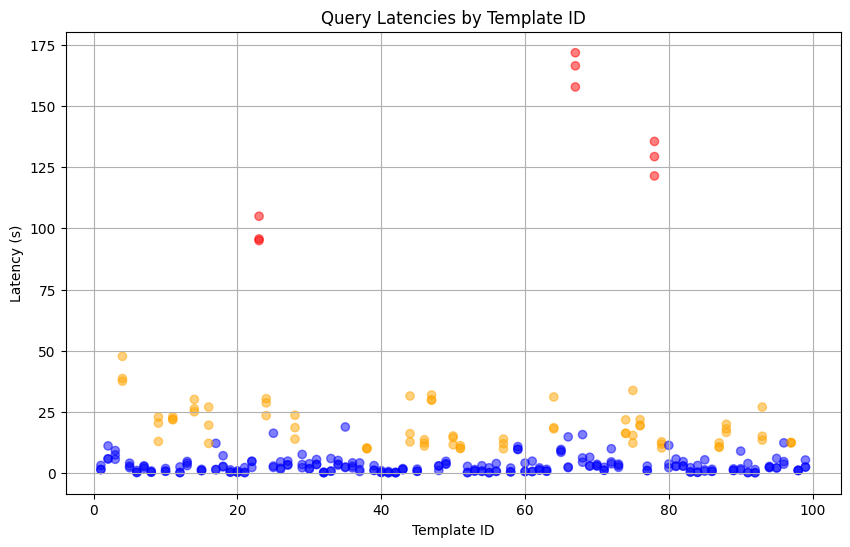

In [19]:
# Plot x axis as template id, y axis as latency.
# Color points over 90 red and points over 10 below 90 orange.
import matplotlib.pyplot as plt

colors = pivoted["median"].map(
    lambda x: "red" if x > 90 else ("orange" if x > 10 else "blue")
)

plt.figure(figsize=(10, 6))
plt.scatter(pivoted.index, pivoted[0], c=colors, alpha=0.5)
plt.scatter(pivoted.index, pivoted[1], c=colors, alpha=0.5)
plt.scatter(pivoted.index, pivoted[2], c=colors, alpha=0.5)
plt.xlabel("Template ID")
plt.ylabel("Latency (s)")
plt.title("Query Latencies by Template ID")
plt.grid(True)
plt.show()

In [20]:
colors.value_counts()

median
blue      73
orange    23
red        3
Name: count, dtype: int64